# ASSIGNMENT 2: Machine Learning
## Review Buster - NLP Classification Model
---

## *Notebook 3*

## III. FINAL MODEL TRAINING AND TEST EVALUATION

**Recall from Notebook 2 — K-Fold Cross Validation.** We compared logistic regression, linear SVM, and a single-hidden-layer MLP using five hotel-grouped folds within the 1,277 training reviews. Each validation run fitted a new TF-IDF vectoriser on its training folds before predicting the held-out fold. We compared unigrams with unigrams + bigrams, with and without lemmatisation, across several regularisation settings. The 319 reviews from four other hotels were kept outside these comparisons.

We selected **`LinearSVC` with non-lemmatised TF-IDF unigrams + bigrams** as the primary model. Its strongest tested setting, `C=10`, achieved a mean deceptive F1 of **0.884** and a mean macro F1 of **0.886** across the five folds. These are cross-validation results, not final test results. Since `C=10` was the largest SVM value tested in Notebook 2, we will examine additional values before fixing the final setting.

**Objective of Notebook 3.** We will keep the selected model family and text representation fixed while tuning the SVM's `C` value. Each candidate will be evaluated on the same five hotel-grouped folds, with TF-IDF fitted separately within each run. We will compare candidates primarily by mean deceptive F1 and choose the best-supported setting using only the training reviews.

After choosing `C`, we will fit one final SVM on Notebook 1's unigram-and-bigram TF-IDF dataframe for all 1,277 training reviews. We will then evaluate it on Notebook 1's matching dataframe for the 319 reviews reserved for final testing. Those test results will describe the selected model's performance; they will not be used to choose another setting.

### 1. Hyperparameter Tuning

#### 1.1) Narrowing the C Range

Notebook 2 selected a linear SVM using non-lemmatised TF-IDF unigrams + bigrams. Of the SVM values tested there (`C=0.1`, `1`, and `10`), `C=10` achieved the highest mean deceptive F1. We now examine values around and above `10` to see whether validation performance improves further or levels off.

We test `C = 1, 3, 5, 10, 20, 30, 50`. This compares the tested settings; it does not identify an exact mathematical optimum. All TF-IDF and SVM settings other than `C` remain the same as in Notebook 2.

For each value, we reuse five hotel-grouped cross-validation folds from the 1,277 training reviews. Each run fits a fresh TF-IDF vectoriser and SVM on four folds, then evaluates the fifth. We compare settings primarily by **mean deceptive F1** and report the mean and sample standard deviation of accuracy, deceptive precision, deceptive recall, deceptive F1, and macro F1. The 319 reviews reserved for final testing are excluded from this search.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display
from sklearn.model_selection import GroupKFold

no_lemma_training_df = pd.read_pickle(
    Path("data/lightly_cleaned_training_df.pkl.gz")
).reset_index(drop=True)

assert len(no_lemma_training_df) == 1277
assert no_lemma_training_df["hotel"].nunique() == 16
assert no_lemma_training_df[["text", "deceptive", "hotel"]].notna().all().all()

# Recreate the same hotel-grouped folds used in Notebook 2.
cv = GroupKFold(n_splits=5)
hotel_fold_splits = list(
    cv.split(
        X=no_lemma_training_df["text"],
        y=no_lemma_training_df["deceptive"],
        groups=no_lemma_training_df["hotel"],
    )
)

# Hotel determines fold membership but is not a predictive input.
no_lemma_model_df = no_lemma_training_df[["text", "deceptive"]].copy()

for train_idx, val_idx in hotel_fold_splits:
    training_hotels = set(no_lemma_training_df.iloc[train_idx]["hotel"])
    validation_hotels = set(no_lemma_training_df.iloc[val_idx]["hotel"])
    assert training_hotels.isdisjoint(validation_hotels)

##### SVM evaluation function

We reuse Notebook 2's evaluation function. It fits a new TF-IDF-and-SVM pipeline for every held-out fold, so that fold cannot influence the vocabulary, IDF weights, or SVM training. The function retains individual fold results for calculating summary statistics, but this notebook displays only the summary for each `C` value.

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)


def evaluate_linear_svm(representation_name, ngram_range, C=1.0):
    fold_results = []

    # Reuse the five hotel-grouped splits prepared above.
    for fold_number, (train_idx, val_idx) in enumerate(
        hotel_fold_splits, start=1
    ):
        train = no_lemma_model_df.iloc[train_idx]
        validation = no_lemma_model_df.iloc[val_idx]

        # Fit a fresh vectoriser and SVM on the four training folds.
        pipeline = Pipeline([
            ("tfidf", TfidfVectorizer(
                ngram_range=ngram_range,
                min_df=2,
                stop_words=None,
                token_pattern=r"(?u)\b\w+(?:['’]\w+)*\b",
                lowercase=False,
                smooth_idf=True,
                norm="l2",
            )),
            ("model", LinearSVC(
                penalty="l2",
                loss="squared_hinge",
                dual="auto",
                C=C,
                fit_intercept=True,
                class_weight=None,
                random_state=42,
                max_iter=5000,
            )),
        ])

        pipeline.fit(train["text"], train["deceptive"])
        predictions = pipeline.predict(validation["text"])

        # Class 1 is deceptive.
        fold_results.append({
            "Representation": representation_name,
            "C": C,
            "Fold": fold_number,
            "Training reviews": len(train),
            "Validation reviews": len(validation),
            "TF-IDF features": len(
                pipeline.named_steps["tfidf"].get_feature_names_out()
            ),
            "Accuracy": accuracy_score(
                validation["deceptive"], predictions
            ),
            "Precision": precision_score(
                validation["deceptive"], predictions
            ),
            "Recall": recall_score(
                validation["deceptive"], predictions
            ),
            "Deceptive F1": f1_score(
                validation["deceptive"], predictions
            ),
            "Macro F1": f1_score(
                validation["deceptive"], predictions,
                average="macro",
            ),
        })

    return pd.DataFrame(fold_results)

##### Validation results across `C` values

We run the selected unigram-and-bigram representation on the same five hotel folds for every `C` value. The table combines each metric's five-fold mean and sample standard deviation. It shows one row per parameter value rather than individual fold results.

In [3]:
c_values = [1.0, 3.0, 5.0, 10.0, 20.0, 30.0, 50.0]

svm_tuning_fold_results = pd.concat(
    [
        evaluate_linear_svm("unigrams + bigrams", (1, 2), C=C)
        for C in c_values
    ],
    ignore_index=True,
)

assert len(svm_tuning_fold_results) == 5 * len(c_values)
assert svm_tuning_fold_results.groupby("C")["Fold"].nunique().eq(5).all()
assert (
    svm_tuning_fold_results
    .groupby("C")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

comparison_metrics = [
    "Accuracy", "Precision", "Recall", "Deceptive F1", "Macro F1"
]

svm_tuning_summary = (
    svm_tuning_fold_results
    .groupby("C")[comparison_metrics]
    .agg(["mean", "std"])
    .sort_index()
)

svm_tuning_table = pd.DataFrame({
    metric: (
        svm_tuning_summary[(metric, "mean")].map("{:.3f}".format)
        + " ± "
        + svm_tuning_summary[(metric, "std")].map("{:.3f}".format)
    )
    for metric in comparison_metrics
}).rename_axis("C")

display(svm_tuning_table)

,Accuracy,Precision,Recall,Deceptive F1,Macro F1
C,,,,,
1.0,0.884 ± 0.031,0.898 ± 0.030,0.869 ± 0.060,0.882 ± 0.036,0.884 ± 0.031
3.0,0.885 ± 0.030,0.898 ± 0.025,0.869 ± 0.055,0.882 ± 0.035,0.884 ± 0.031
5.0,0.886 ± 0.031,0.898 ± 0.026,0.870 ± 0.055,0.883 ± 0.035,0.886 ± 0.031
10.0,0.886 ± 0.028,0.898 ± 0.027,0.872 ± 0.055,0.884 ± 0.031,0.886 ± 0.028
20.0,0.886 ± 0.028,0.898 ± 0.027,0.872 ± 0.055,0.884 ± 0.031,0.886 ± 0.028
30.0,0.885 ± 0.027,0.896 ± 0.025,0.872 ± 0.055,0.883 ± 0.031,0.885 ± 0.027
50.0,0.885 ± 0.027,0.896 ± 0.025,0.872 ± 0.055,0.883 ± 0.031,0.885 ± 0.027


**Observations from the first `C` search.** `C=10` and `C=20` are the two strongest candidates: both reached an unrounded mean deceptive F1 of **0.884121** and a displayed mean macro F1 of **0.886** across the five hotel-grouped folds. Increasing `C` further did not help; mean deceptive F1 was approximately **0.883** at both `C=30` and `C=50`.

Increasing `C` weakens the SVM's regularisation. Because `C=20` gave no observed improvement over `C=10`, we will carry **`C=10`** forward as the leading setting. It keeps a stronger penalty on large model weights than `C=20` without sacrificing the observed validation performance. The differences across the broader grid are small relative to fold-to-fold variation, so these results do not establish a precise optimum.

We will now look more closely at values around `C=10`, particularly values below it, to see whether stronger regularisation can match its mean deceptive F1. This comparison will still use only the training reviews; the 319 held-out test reviews remain untouched.

#### 1.2) Closer Look Around `C=10`

Section 1.1 found that `C=10` and `C=20` had the highest mean deceptive F1 among its tested values. We carried `C=10` forward because increasing `C` weakens regularisation without an observed validation benefit. We now check whether a nearby, smaller value can match or improve its result while retaining a stronger penalty on large model weights.

We test `C` from **5.0 through 15.0 in steps of 0.1**, giving 101 settings. We reuse the same five hotel-grouped folds and the `evaluate_linear_svm` function from Section 1.1. Only `C` changes. Mean deceptive F1 remains our primary selection metric; the other validation metrics help us interpret the results. The 319 reviews reserved for final testing remain outside this search.

##### Running the finer `C` grid

For each setting, the function fits a fresh TF-IDF vectoriser and SVM on four training folds, then evaluates the fifth fold. It records five results per setting for the summary below; individual fold tables will not be displayed.

In [4]:
# Generate 101 candidate values: 5.0, 5.1, ..., 15.0.
fine_c_values = [
    round(5.0 + 0.1 * step, 1)
    for step in range(101)
]

# Verify that the grid has the intended number of values and endpoints.
assert len(fine_c_values) == 101
assert fine_c_values[0] == 5.0
assert fine_c_values[-1] == 15.0

# Run the existing five-fold SVM evaluation function for every value.
# The function refits TF-IDF and the SVM within each training-fold group.
svm_fine_tuning_fold_results = pd.concat(
    [
        evaluate_linear_svm("unigrams + bigrams", (1, 2), C=C)
        for C in fine_c_values
    ],
    ignore_index=True,
)

# Confirm that each setting has five fold results and that its
# validation folds together cover all 1,277 training reviews.
assert len(svm_fine_tuning_fold_results) == 5 * len(fine_c_values)
assert (
    svm_fine_tuning_fold_results
    .groupby("C")["Fold"]
    .nunique()
    .eq(5)
    .all()
)
assert (
    svm_fine_tuning_fold_results
    .groupby("C")["Validation reviews"]
    .sum()
    .eq(1277)
    .all()
)

##### Comparing validation metrics

The first table has one row for each of the 101 tested values. Each metric is shown as its **mean ± sample standard deviation** across five held-out hotel folds. The second table shows only values tied for the highest **unrounded mean deceptive F1**. Display rounding does not determine which rows are selected.

In [5]:
# Calculate the five-fold mean and sample standard deviation of each
# validation metric for every C value.
svm_fine_tuning_summary = (
    svm_fine_tuning_fold_results
    .groupby("C")[comparison_metrics]
    .agg(["mean", "std"])
    .sort_index()
)

# Format each metric as "mean ± standard deviation" for the report.
# Keep the unrounded summary above for selecting the strongest setting.
svm_fine_tuning_table = pd.DataFrame({
    metric: (
        svm_fine_tuning_summary[(metric, "mean")].map("{:.3f}".format)
        + " ± "
        + svm_fine_tuning_summary[(metric, "std")].map("{:.3f}".format)
    )
    for metric in comparison_metrics
}).rename_axis("C")

# Display every tested parameter setting, without individual fold rows.
with pd.option_context("display.max_rows", len(svm_fine_tuning_table)):
    display(svm_fine_tuning_table)

# Identify the highest unrounded mean deceptive F1 and all C values
# tied for that score. The tolerance handles numerical equality.
mean_deceptive_f1 = svm_fine_tuning_summary[("Deceptive F1", "mean")]
highest_mean_f1 = mean_deceptive_f1.max()
best_c_values = mean_deceptive_f1.index[
    (mean_deceptive_f1 - highest_mean_f1).abs() <= 1e-12
].tolist()

# Display only the rows selected by that stated performance rule.
display(svm_fine_tuning_table.loc[best_c_values])

# When performance ties, choose the smaller C for stronger regularisation.
selected_c = min(best_c_values)
print(f"Highest observed mean deceptive F1: {highest_mean_f1:.6f}")
print(f"C values tied for that score: {best_c_values}")
print(f"Selected C among the tied values: {selected_c:g}")
print(f"C=10 mean deceptive F1 for comparison: {mean_deceptive_f1.loc[10.0]:.6f}")

,Accuracy,Precision,Recall,Deceptive F1,Macro F1
C,,,,,
5.0,0.886 ± 0.031,0.898 ± 0.026,0.870 ± 0.055,0.883 ± 0.035,0.886 ± 0.031
5.1,0.886 ± 0.031,0.898 ± 0.026,0.870 ± 0.055,0.883 ± 0.035,0.886 ± 0.031
5.2,0.887 ± 0.031,0.899 ± 0.026,0.872 ± 0.057,0.884 ± 0.035,0.886 ± 0.031
5.3,0.887 ± 0.031,0.899 ± 0.026,0.872 ± 0.057,0.884 ± 0.035,0.886 ± 0.031
5.4,0.886 ± 0.030,0.899 ± 0.025,0.871 ± 0.056,0.884 ± 0.034,0.886 ± 0.030
5.5,0.886 ± 0.030,0.899 ± 0.025,0.871 ± 0.056,0.884 ± 0.034,0.886 ± 0.030
5.6,0.887 ± 0.028,0.899 ± 0.025,0.872 ± 0.053,0.885 ± 0.032,0.887 ± 0.028
5.7,0.887 ± 0.028,0.899 ± 0.025,0.872 ± 0.053,0.885 ± 0.032,0.887 ± 0.028
5.8,0.887 ± 0.028,0.899 ± 0.025,0.872 ± 0.053,0.885 ± 0.032,0.887 ± 0.028


,Accuracy,Precision,Recall,Deceptive F1,Macro F1
C,,,,,
6.0,0.888 ± 0.026,0.899 ± 0.025,0.874 ± 0.049,0.886 ± 0.030,0.888 ± 0.027
6.1,0.888 ± 0.026,0.899 ± 0.025,0.874 ± 0.049,0.886 ± 0.030,0.888 ± 0.027


Highest observed mean deceptive F1: 0.885919
C values tied for that score: [6.0, 6.1]
Selected C among the tied values: 6
C=10 mean deceptive F1 for comparison: 0.884121


**Observations from the finer `C` search.** The highest unrounded mean deceptive F1 is **0.885919**, reached at both `C=6.0` and `C=6.1`. Their mean macro F1 is **0.887622**. Because their primary validation scores tie, we select **`C=6.0`**: it retains slightly stronger regularisation.

At the previous leading setting, `C=10`, mean deceptive F1 is **0.884121**. The observed gain at `C=6.0` is approximately **0.0018**, much smaller than the fold-to-fold deceptive-F1 standard deviation of approximately **0.030**. Thus, `C=6.0` is the best setting *observed in this search*, but these five folds do not establish a reliable performance advantage over `C=10` on future hotels.

The 101 tested values produced only **eight distinct mean deceptive-F1 scores**. Many neighbouring values therefore have the same measured performance; the fine grid should not be interpreted as locating an exact optimum. All choices in this section were based on the 1,277 training reviews. The 319 held-out test reviews remain unused.

#### 1.3) Summary - Final Selection

We select **`LinearSVC(C=6.0)`** as Review Buster's final model setting, using **non-lemmatised TF-IDF unigrams + bigrams**. In the finer hotel-grouped cross-validation search, `C=6.0` and `C=6.1` tied for the highest mean deceptive F1 (**0.885919**). We chose `C=6.0` under our tie rule: when validation performance is equal, prefer the smaller `C` for slightly stronger regularisation.

This fixes the configuration before final testing. Next, we will train the SVM on Notebook 1's TF-IDF dataframe for all **1,277 training reviews**, then evaluate it on the matching dataframe for the **319 reserved test reviews**. Those test results will assess the selected model; they will not be used to change `C`.

### 2. Final Training & Evaluating Performance on Testing Data Frame

We have selected `LinearSVC(C=6.0)` using non-lemmatised TF-IDF unigrams + bigrams. We now fit this model on all **1,277 training reviews** and evaluate it on the **319 reviews from four hotels reserved for final testing**.

We reuse Notebook 1's saved TF-IDF dataframes. Its vectoriser learned the vocabulary and IDF weights from the training reviews, then transformed the held-out reviews using that fitted representation. Both dataframes therefore contain the same 23,598 text features. The file named `unigram_bigram_validation_df.pkl.gz` represents our final test set here.

The model receives only the `tfidf_...` columns. `deceptive` supplies the target labels, while `hotel`, `source`, and `polarity` remain available for analysis. The model settings are now fixed; the test results will be used to assess and explain its performance.

#### 2.1) Preparing the Final Training and Test Inputs

We load both saved dataframes and check their review counts, hotel separation, and feature-column order. We then convert their TF-IDF columns into sparse matrices, preserving the numerical representation already prepared in Notebook 1.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# Load Notebook 1's existing unigram-and-bigram TF-IDF dataframes.
final_training_df = pd.read_pickle(
    Path("data/unigram_bigram_training_df.pkl.gz")
).reset_index(drop=True)
final_test_df = pd.read_pickle(
    Path("data/unigram_bigram_validation_df.pkl.gz")
).reset_index(drop=True)

# Check that the original training/test split has been preserved.
assert len(final_training_df) == 1277
assert len(final_test_df) == 319
assert final_training_df["hotel"].nunique() == 16
assert final_test_df["hotel"].nunique() == 4
assert set(final_training_df["hotel"]).isdisjoint(final_test_df["hotel"])

# Select only text features and verify their order in both dataframes.
final_feature_columns = [
    column for column in final_training_df.columns
    if column.startswith("tfidf_")
]
test_feature_columns = [
    column for column in final_test_df.columns
    if column.startswith("tfidf_")
]
assert final_feature_columns == test_feature_columns
assert len(final_feature_columns) == 23598

# Preserve the sparse representation when preparing inputs for LinearSVC.
X_final_train = (
    final_training_df[final_feature_columns].sparse.to_coo().tocsr()
)
X_final_test = (
    final_test_df[final_feature_columns].sparse.to_coo().tocsr()
)

# Keep target labels separate from the predictive inputs.
y_final_train = final_training_df["deceptive"].copy()
y_final_test = final_test_df["deceptive"].copy()
assert set(y_final_train.unique()) == {0, 1}
assert set(y_final_test.unique()) == {0, 1}

# Show the exact sample sizes used for training and final testing.
final_data_summary = pd.DataFrame({
    "Reviews": [len(final_training_df), len(final_test_df)],
    "Hotels": [
        final_training_df["hotel"].nunique(),
        final_test_df["hotel"].nunique(),
    ],
    "Truthful": [
        int(y_final_train.eq(0).sum()),
        int(y_final_test.eq(0).sum()),
    ],
    "Deceptive": [
        int(y_final_train.eq(1).sum()),
        int(y_final_test.eq(1).sum()),
    ],
    "TF-IDF features": [X_final_train.shape[1], X_final_test.shape[1]],
}, index=["Training", "Final test"])
display(final_data_summary)

,Reviews,Hotels,Truthful,Deceptive,TF-IDF features
Training,1277,16,637,640,23598
Final test,319,4,159,160,23598


#### 2.2) Final Evaluation Function

The evaluation function receives an already fitted SVM. It produces class predictions, obtains decision scores, and calculates:

- **Accuracy:** the proportion of reviews classified correctly.
- **Deceptive precision:** the proportion of flagged reviews that are labelled deceptive.
- **Deceptive recall:** the proportion of deceptive reviews detected.
- **Deceptive F1:** the harmonic mean of deceptive precision and recall.
- **Macro F1:** the mean of the truthful and deceptive class F1 scores.
- **ROC-AUC:** how well the decision scores rank deceptive reviews above truthful reviews.
- **Average precision:** a summary of the precision–recall relationship across decision thresholds.

`LinearSVC` produces decision scores rather than probabilities. We use its class predictions for accuracy, precision, recall, and F1, and its decision scores for ROC-AUC and average precision. We retain the classifier's default decision rule.

We also evaluate the fitted model on its training data to describe the difference between training and test performance. Training scores are diagnostic; the reserved test results assess performance on unseen hotels.

In [2]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

def evaluate_final_svm(model, X, y):
    # Obtain labels and decision scores without changing the fitted model.
    predictions = model.predict(X)
    decision_scores = model.decision_function(X)

    # Class 1 is deceptive. Hard-label metrics use predictions;
    # ranking metrics use the continuous SVM decision scores.
    metrics = pd.Series({
        "Accuracy": accuracy_score(y, predictions),
        "Precision": precision_score(
            y, predictions, pos_label=1, zero_division=0
        ),
        "Recall": recall_score(
            y, predictions, pos_label=1, zero_division=0
        ),
        "Deceptive F1": f1_score(
            y, predictions, pos_label=1, zero_division=0
        ),
        "Macro F1": f1_score(
            y, predictions, average="macro", zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y, decision_scores),
        "Average precision": average_precision_score(y, decision_scores),
    })

    # Retain predictions and scores for plots and error analysis.
    return metrics, predictions, decision_scores

#### 2.3) Training the Final SVM and Predicting the Test Reviews

We create one SVM with `C=6.0` and retain the other settings used during cross-validation. Fitting on all 1,277 training reviews learns one final set of feature weights and an intercept.

We then apply that fitted model to the training and test matrices. Each test metric is calculated over all 319 held-out reviews. These are single test-set estimates, so we do not attach the fold standard deviations used in Section 1.

In [3]:
import warnings

from sklearn.exceptions import ConvergenceWarning
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# Fix the configuration selected through training-only cross-validation.
final_svm = LinearSVC(
    penalty="l2",
    loss="squared_hinge",
    dual="auto",
    C=6.0,
    fit_intercept=True,
    class_weight=None,
    random_state=42,
    max_iter=5000,
)

# Fit one model using every training review.
# Stop if the solver reports non-convergence before evaluating the test set.
with warnings.catch_warnings():
    warnings.simplefilter("error", ConvergenceWarning)
    final_svm.fit(X_final_train, y_final_train)

# Confirm that positive decision scores correspond to deceptive class 1.
assert final_svm.classes_.tolist() == [0, 1]

# Measure training performance as a diagnostic.
train_metrics, train_predictions, train_scores = evaluate_final_svm(
    final_svm, X_final_train, y_final_train
)

# Generate the fixed model's final test predictions and scores.
test_metrics, test_predictions, test_scores = evaluate_final_svm(
    final_svm, X_final_test, y_final_test
)

# Compare training and final test metrics without rounding stored values.
final_metric_table = pd.DataFrame(
    [train_metrics, test_metrics],
    index=["Training", "Final test"],
)
display(final_metric_table.round(3))

# Report both classes separately, including their test sample counts.
test_class_report = pd.DataFrame(
    classification_report(
        y_final_test,
        test_predictions,
        labels=[0, 1],
        target_names=["Truthful (0)", "Deceptive (1)"],
        output_dict=True,
        zero_division=0,
    )
).T.loc[["Truthful (0)", "Deceptive (1)"]]
test_class_report["support"] = test_class_report["support"].astype(int)
display(test_class_report.round(3))

,Accuracy,Precision,Recall,Deceptive F1,Macro F1,ROC-AUC,Average precision
Training,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Final test,0.881,0.918,0.838,0.876,0.881,0.949,0.954


,precision,recall,f1-score,support
Truthful (0),0.850,0.925,0.886,159
Deceptive (1),0.918,0.838,0.876,160


#### 2.4) Confusion Matrix, ROC Curve, and Precision–Recall Curve

The confusion matrix shows the model's decisions at its fixed default threshold. A **false positive** is a truthful review flagged as deceptive; a **false negative** is a deceptive review classified as truthful. False positives may unfairly discredit genuine reviewers, while false negatives allow deceptive reviews to pass undetected.

The ROC curve shows the relationship between deceptive recall and the false-positive rate across thresholds. The precision–recall curve shows how the precision of deceptive flags changes as more deceptive reviews are detected. Average precision summarises the latter curve; it is reported separately from ROC-AUC.

The marked point on each curve represents the classifier's default decision rule, with the boundary at decision score zero. The curves describe the fixed model's scores; we will not use the test set to choose a different threshold.

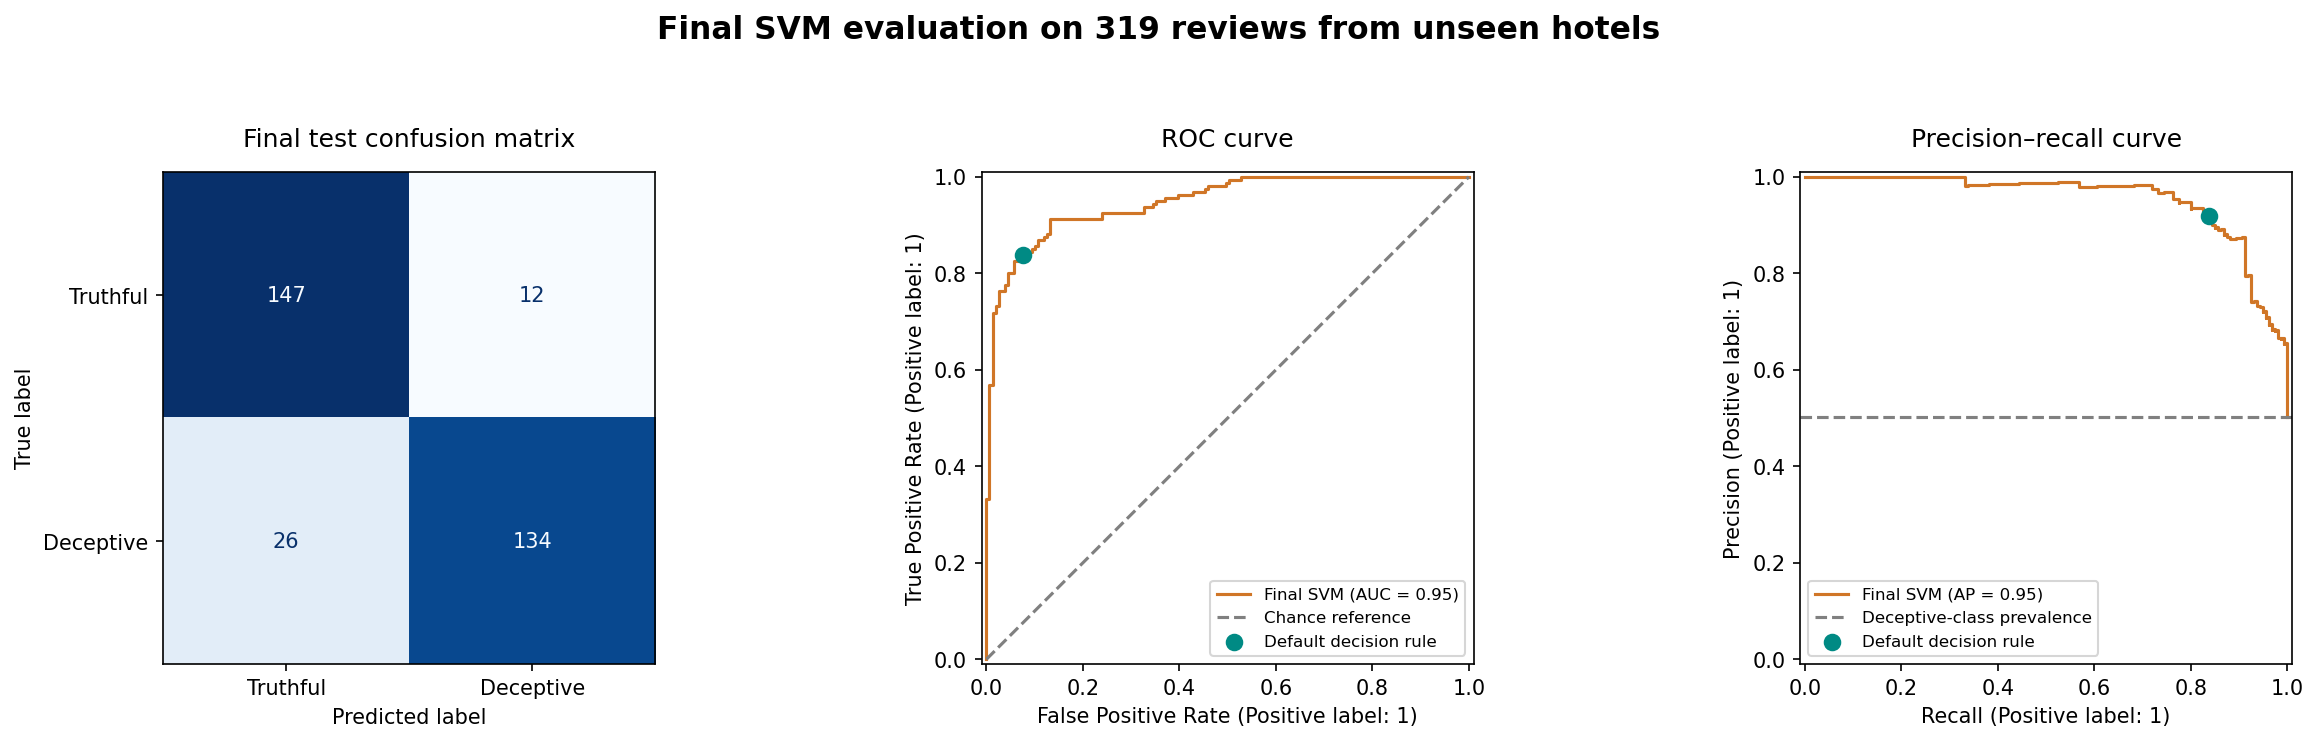

Truthful reviews incorrectly flagged as deceptive: 12
Deceptive reviews incorrectly classified as truthful: 26


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# Count correct predictions and both types of classification error.
test_confusion_matrix = confusion_matrix(
    y_final_test, test_predictions, labels=[0, 1]
)
tn, fp, fn, tp = test_confusion_matrix.ravel()

# Present three complementary views of the same final test predictions.
fig, axes = plt.subplots(1, 3, figsize=(17, 5.0), dpi=150)
fig.patch.set_facecolor("white")

# Show the actual number of reviews in each confusion-matrix cell.
ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=["Truthful", "Deceptive"],
).plot(
    ax=axes[0], cmap="Blues", values_format="d", colorbar=False
)
axes[0].set_title("Final test confusion matrix", pad=12)

# Plot ranking performance from the SVM's continuous decision scores.
RocCurveDisplay.from_predictions(
    y_final_test, test_scores, name="Final SVM",
    ax=axes[1], color="#d07627",
)
axes[1].plot(
    [0, 1], [0, 1], linestyle="--", color="grey",
    label="Chance reference",
)
axes[1].scatter(
    fp / (fp + tn), tp / (tp + fn),
    color="#008a84", s=55, label="Default decision rule", zorder=3,
)
axes[1].set_title("ROC curve", pad=12)
axes[1].legend(loc="lower right", fontsize=8)

# Plot precision and recall for the deceptive class across thresholds.
PrecisionRecallDisplay.from_predictions(
    y_final_test, test_scores, name="Final SVM",
    ax=axes[2], color="#d07627",
)

# Use the deceptive-class prevalence as a reference precision.
axes[2].axhline(
    y_final_test.mean(), linestyle="--", color="grey",
    label="Deceptive-class prevalence",
)
axes[2].scatter(
    test_metrics["Recall"], test_metrics["Precision"],
    color="#008a84", s=55, label="Default decision rule", zorder=3,
)
axes[2].set_title("Precision–recall curve", pad=12)
axes[2].legend(loc="lower left", fontsize=8)

fig.suptitle(
    "Final SVM evaluation on 319 reviews from unseen hotels",
    fontsize=15, fontweight="semibold",
)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

# State the practical error counts below the figure.
print(f"Truthful reviews incorrectly flagged as deceptive: {fp}")
print(f"Deceptive reviews incorrectly classified as truthful: {fn}")

#### 2.5) Performance Across Hotels and Review Errors

The overall test score combines reviews from four hotels. We inspect each hotel's results to check whether the overall score conceals a weaker group. These smaller groups provide descriptive evidence; four hotels cannot establish performance across all future hotels.

We retain each review's true label, prediction, and decision score for error inspection. Hotel, source, and polarity are used only to describe the results.

In [5]:
# Combine the fixed predictions with metadata for error analysis.
test_prediction_df = final_test_df[
    ["deceptive", "hotel", "polarity", "source"]
].copy()
test_prediction_df["Predicted label"] = test_predictions
test_prediction_df["Decision score"] = test_scores

# Identify false positives and false negatives for later inspection.
test_prediction_df["Error type"] = np.select(
    [
        test_prediction_df["deceptive"].eq(0)
        & test_prediction_df["Predicted label"].eq(1),
        test_prediction_df["deceptive"].eq(1)
        & test_prediction_df["Predicted label"].eq(0),
    ],
    ["False positive", "False negative"],
    default="Correct",
)

# Summarise the same final predictions for each held-out hotel.
hotel_result_rows = []
for hotel, group in test_prediction_df.groupby("hotel", sort=True):
    hotel_result_rows.append({
        "Hotel": hotel,
        "Reviews": len(group),
        "Truthful": int(group["deceptive"].eq(0).sum()),
        "Deceptive": int(group["deceptive"].eq(1).sum()),
        "False positives": int(group["Error type"].eq("False positive").sum()),
        "False negatives": int(group["Error type"].eq("False negative").sum()),
        "Deceptive F1": f1_score(
            group["deceptive"], group["Predicted label"], zero_division=0
        ),
        "Macro F1": f1_score(
            group["deceptive"], group["Predicted label"],
            average="macro", zero_division=0,
        ),
    })

hotel_result_table = pd.DataFrame(hotel_result_rows).set_index("Hotel")
display(hotel_result_table.round(3))

,Reviews,Truthful,Deceptive,False positives,False negatives,Deceptive F1,Macro F1
Hotel,,,,,,,
allegro,80,40,40,5,4,0.889,0.887
homewood,80,40,40,2,9,0.849,0.861
knickerbocker,80,40,40,2,5,0.909,0.912
monaco,79,39,40,3,8,0.853,0.860


##### Inspecting misclassified reviews

The saved TF-IDF dataframes omit readable text. We retrieve the original reviews using Notebook 1's duplicate removal and hotel allocation, then verify their metadata alignment before attaching text.

For each error type, we display up to three reviews with the strongest decision scores in the wrong direction. This fixed selection rule highlights cases to investigate; these examples are not a random or representative sample of all errors. Large decision-score magnitudes should not be interpreted as calibrated confidence probabilities.

In [6]:
# Retrieve original text for explaining errors without modifying the model.
raw_review_df = (
    pd.read_csv(Path("data/deceptive-opinion.csv"))
    .drop_duplicates()
    .reset_index(drop=True)
)

# Match Notebook 1's label and polarity encodings.
raw_review_df["deceptive"] = (
    raw_review_df["deceptive"]
    .map({"truthful": 0, "deceptive": 1}).astype("int8")
)
raw_review_df["polarity"] = (
    raw_review_df["polarity"]
    .map({"negative": 0, "positive": 1}).astype("int8")
)

# Preserve the original row order within the held-out hotels.
test_review_text_df = raw_review_df.loc[
    raw_review_df["hotel"].isin(final_test_df["hotel"].unique())
].reset_index(drop=True)

# Check metadata alignment before attaching readable review text.
metadata_columns = ["deceptive", "hotel", "polarity", "source"]
assert test_review_text_df[metadata_columns].equals(
    final_test_df[metadata_columns]
)
test_prediction_df["Review text"] = test_review_text_df["text"]

# Inspect errors with the strongest scores in the wrong direction.
error_display_columns = [
    "hotel", "deceptive", "Predicted label", "Decision score", "Review text"
]
for error_type, ascending in [
    ("False positive", False),
    ("False negative", True),
]:
    examples = (
        test_prediction_df.loc[
            test_prediction_df["Error type"].eq(error_type)
        ]
        .sort_values("Decision score", ascending=ascending)
        .head(3)
    )
    print(error_type)
    with pd.option_context("display.max_colwidth", None):
        display(examples[error_display_columns])

False positive


,hotel,deceptive,Predicted label,Decision score,Review text
47,monaco,0,1,0.684546,A friend highly recommended this hotel and we couldn't have been happier! It was wonderful ~ my husband and kids were already planning our next trip there before we had even left the hotel. The kids loved the goldfish in the room and thought the window seats were the best. \n
14,homewood,0,1,0.400182,"I visited Chicago with my two teenage daughters. Homewood Suites is amazing. The complimentary breakfast and receptions offer so much variety. The hotel was within walking distance to many places to eat and shop. We got caught in a thunderstorm, and got soaking wet. I dried all our clothes in the dryer right in the hotel! The Homewood Suites was so much like home. The suite was very spacious and had everything we needed. The hotel had lots of brochures and suggestions for dining and activities. The staff was so friendly and helpful. Chicago is an amazing place and the Homewood Suites is the place to stay. I would definitely stay there again. \n"
209,monaco,0,1,0.209103,"This was a refreshing change from the ordinary. I loved the location, the service and the amenities offered by this hotel. The room was charming with a window seat and a water view. The decor was unique but cheerful. Free wireless internet services were a plus here. The staff was helpful and attentive. We loved having goldfish share our room! I would definitely stay here again.\n"


False negative


,hotel,deceptive,Predicted label,Decision score,Review text
318,allegro,1,0,-0.679163,"I have been stayed in Allegro for two days. There are not other big prolems but one thing I'm not satisfied with is the light. It is dark in the room. Also in the bathroom, the light is not good. I have to open curtains. I have complained about this to their reception. They said they will fix it, but I did not get any response. I am very disappointed and I will never come back again.\n"
83,homewood,1,0,-0.641688,"I work for a software marketing firm, and that job requires me to travel at least 100 days per year. I spend a large amount of time in hotels. I normally don't write reviews for hotels, but the Homewood Suites by Hilton were above and beyond. Let's start where it matters: the rooms. They are top notch. There's nothing better than walking in to a clean, beautiful rooms after a long day of travel. The beds are among the best I've ever slept in in hotels. The rest of the room is just as nice and makes me feel at home. The price: Low. I looked for similar rooms in the area at other hotels, and everything else was at least 10% more expensive. But you don't get what you pay for here. You get much more than that! The location: Couldn't be better. You want to go to a world class restaurant? That's within walking distance. You want a great shopping experience? Again, walking distance. Anything else you want? Chances are, it's within walking distance. Overall, one of the best hotels I've ever stayed in.\n"
275,knickerbocker,1,0,-0.637902,"We stayed in the Millennium Knickerbocker Hotel Chicago in a standard guest room. The rooms had just been renovated, but the changes did not make much of a difference. The room was so small, it felt like we were sleeping below deck on a boat. The decor was drab and there was nothing special about the room. We were excited about the bathrobe and slippers that came with the room, but we assumed there would be a bathrobe and a pair of slippers for each of us; there was only one bathrobe and one pair of slippers. We called the front desk to ask for a second set and were treated like we were trying to scam the hotel and refused to send them. It would not have mattered if they sent a second set; the bathrobe was so scratchy it gave me a rash and there were stains on the slippers. As hotel guests, we expected to be treated with respect and enjoy the stay we paid for. We were severely disappointed.\n"


#### 2.6) Interpretation and Limitations

**Overall test performance.** The final SVM correctly classified **281 of 319 reviews**, giving accuracy **0.881**, deceptive F1 **0.876**, and macro F1 **0.881**. Deceptive precision was **0.918** and recall was **0.838**. Of 146 reviews flagged as deceptive, 134 were labelled deceptive in the corpus. However, the model missed **26 of the 160 deceptive reviews (16.25%)**, and incorrectly flagged **12 of the 159 truthful reviews (7.55%)**.

**Training, cross-validation, and testing.** The final model achieved perfect classification on its training data, while its test accuracy was 0.881. This demonstrates a generalisation gap and shows why training scores alone are insufficient. Test deceptive F1 (0.875817) was approximately **0.010 lower** than the selected five-fold mean (0.885919). Those figures use different review groups, training sizes, and aggregation methods; their difference alone cannot establish a statistically reliable decline. Cross-validation also selected the model settings, whereas this fixed test set supplied an independent final assessment.

**Ranking and the default decision rule.** ROC-AUC was **0.949** and average precision was **0.954**, indicating strong separation in the model's decision scores on these test reviews. At the default threshold, deceptive precision exceeded recall, so the model missed more deceptive reviews than it incorrectly flagged truthful ones. The plotted curves describe this trade-off, but we retain the decision rule fixed before testing. Decision scores are not calibrated probabilities.

**Differences across hotels.** Deceptive F1 ranged from **0.849 for Homewood** to **0.909 for Knickerbocker**. Allegro scored 0.889 and Monaco scored 0.853. Homewood and Monaco contributed **17 of the 26 false negatives**, despite containing only 80 of the 160 deceptive test reviews. This identifies where missed deception was concentrated in this split, but does not establish why those hotels were harder. Each hotel has only 79 or 80 reviews, so these subgroup results are descriptive.

**What the selected errors show.** The displayed false positives are favourable reviews with personal experiences and hotel details, such as a family visit, the complimentary breakfast, and the Monaco's goldfish. The displayed false negatives also contain plausible detail: lighting complaints, a business traveller's account, and a complaint about room amenities. These examples illustrate that detailed or personal language can appear in both classes. They characterise the selected errors; establishing which words drove each prediction would require feature-contribution analysis. The strongest wrong-direction examples are not a representative sample of all errors.

**Training objective and practical consequences.** The SVM minimises a regularised squared-hinge objective, which penalises margin violations. It does not directly maximise F1 or encode the different practical costs of false accusations and missed deception. Precision, recall, and the confusion matrix therefore provide checks beyond the training objective. In a moderation setting, predictions would be flags for human review. Any future threshold or model changes should be developed using training data and assessed with new independent test data.

**Scope of the conclusion.** These results assess the corpus's truthful/deceptive labels on four held-out hotels. Excluding source metadata does not remove source-related writing patterns from the text. The experiment therefore supports a limited claim about this human-written hotel-review corpus; it does not prove that an individual reviewer lied, establish performance across all hotels, or measure detection of AI-generated reviews.

### 3. Conclusion

Notebook 2 selected a linear SVM with non-lemmatised TF-IDF unigrams and bigrams. Section 1 of this notebook selected **`C=6.0`** using hotel-grouped cross-validation on the training reviews. We then fitted one final SVM on all **1,277 training reviews** and evaluated it on **319 reviews from four previously unseen hotels**.

On that final test set, the model achieved **0.881 accuracy**, **0.876 deceptive F1**, and **0.881 macro F1**. It detected **134 of 160 deceptive reviews**, missed **26**, and incorrectly flagged **12 of 159 truthful reviews**. These results show useful performance on the reserved hotels, with missed deceptive reviews remaining the more frequent error at the fixed decision rule.

The result is limited to this corpus and four held-out hotels; it cannot establish how well the model will work for every future hotel or determine whether any individual reviewer lied. If missing deceptive reviews is especially costly, a future study could assess class weighting or a different decision cutoff using **training-only hotel-grouped validation**, followed by a new independent test. The reported test result remains the assessment of the already selected model.